### Scott 10K 1v1

#### We have a classifier that works well - LR Desikan, with surrogate modelling by XGBoost.
#### Now, how does that compare with VBM and SBM measures?
#### Solution: Compare LR Desikan beta coefficeints against a whole bunch of classifiers trained and tested on (a) Desikan VBM ROI data (b) Recon-all cortical thicknesses and (c) Recon-all ROI GMVs

In [1]:
%%bash

mkdir -p /rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/1v1

In [2]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score 
from matplotlib import font_manager


font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

scaler = StandardScaler()

seed = 42

kf = KFold()

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

rf = RandomForestClassifier(random_state = seed, class_weight = 'balanced')

svc = SVC(random_state = seed, probability = True, class_weight = 'balanced', kernel = 'rbf') # default kernel is linear which is unfair for non-linearly separable data

knn = KNeighborsClassifier()

gnb = GaussianNB()

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

raw_desikan_cort_thick = [col for col in df.columns.tolist() if 'aparc_thickness' in col]
raw_desikan_cort_thick_banned = ['lh_MeanThickness_thickness_aparc_thickness_lh', 'BrainSegVolNotVent_aparc_thickness_lh', 
                                 'eTIV_aparc_thickness_lh', 'rh_MeanThickness_thickness_aparc_thickness_rh', 
                                 'BrainSegVolNotVent_aparc_thickness_rh', 'eTIV_aparc_thickness_rh']
raw_desikan_roi_gmv = [col for col in df.columns.tolist() if 'aparc_volume' in col or 'aseg_stats' in col]
raw_desikan_roi_gmv_banned = list(set(['Right-Cerebellum-White-Matter_aseg_stats', 'Brain-Stem_aseg_stats', 
                                       'CSF_aseg_stats','Left-vessel_aseg_stats', 'Left-choroid-plexus_aseg_stats',
                                       'Right-Lateral-Ventricle_aseg_stats' ,'Right-Inf-Lat-Vent_aseg_stats',
                                       '3rd-Ventricle_aseg_stats','4th-Ventricle_aseg_stats',
                                       'BrainSegVolNotVent_aparc_volume_lh', 'BrainSegVolNotVent_aparc_volume_rh', 
                                       'Left-Lateral-Ventricle_aseg_stats', 'Left-Inf-Lat-Vent_aseg_stats', 
                                       'Left-Cerebellum-White-Matter_aseg_stats', 'Right-vessel_aseg_stats', 
                                       'Right-choroid-plexus_aseg_stats', '5th-Ventricle_aseg_stats', 
                                       'WM-hypointensities_aseg_stats', 'Left-WM-hypointensities_aseg_stats', 
                                       'Right-WM-hypointensities_aseg_stats', 'non-WM-hypointensities_aseg_stats', 
                                       'Left-non-WM-hypointensities_aseg_stats', 'Right-non-WM-hypointensities_aseg_stats', 
                                       'Optic-Chiasm_aseg_stats', 'CC_Posterior_aseg_stats', 'CC_Mid_Posterior_aseg_stats', 
                                       'CC_Central_aseg_stats', 'CC_Mid_Anterior_aseg_stats', 'CC_Anterior_aseg_stats', 
                                       'BrainSegVol_aseg_stats', 'BrainSegVolNotVent_aseg_stats', 'lhCortexVol_aseg_stats', 
                                       'rhCortexVol_aseg_stats', 'CortexVol_aseg_stats', 'lhCerebralWhiteMatterVol_aseg_stats', 
                                       'rhCerebralWhiteMatterVol_aseg_stats', 'CerebralWhiteMatterVol_aseg_stats', 'SubCortGrayVol_aseg_stats', 
                                       'TotalGrayVol_aseg_stats', 'SupraTentorialVol_aseg_stats', 'SupraTentorialVolNotVent_aseg_stats', 
                                       'MaskVol_aseg_stats', 'BrainSegVol-to-eTIV_aseg_stats', 'MaskVol-to-eTIV_aseg_stats', 'lhSurfaceHoles_aseg_stats', 
                                       'rhSurfaceHoles_aseg_stats', 'SurfaceHoles_aseg_stats']))


column_dicts = {
    'desikan_coeffs' : ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR'],
    'desikan_vbm' : [col for col in df.columns.tolist() if 'desikan_vbm' in col],
    'desikan_cort_thick' : [col for col in raw_desikan_cort_thick if col not in raw_desikan_cort_thick_banned],
    'desikan_roi_gmv' :  [col for col in raw_desikan_roi_gmv if col not in raw_desikan_roi_gmv_banned]}





for key,val in column_dicts.items():

    df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)
    df = df[(df['DIAGNOSIS'] == 1) | (df['DIAGNOSIS'] == 3)]
    desikan_df = df[['DIAGNOSIS'] + column_dicts[key]].dropna()
    desikan_df = desikan_df.apply(pd.to_numeric, errors = 'coerce')
    print(desikan_df.dtypes)
    X = desikan_df.drop(columns = 'DIAGNOSIS')
    y = desikan_df['DIAGNOSIS'].map(lambda x: 0 if x == 1 else 1)
    
    print(f'Processing {key} : shape of available data = {X.shape}')

    xgb_balancer = float(y[y == 0].shape[0])/ float(y[y == 1].shape[0])
    print(xgb_balancer)

    ## Instantiate xgb with the balancer - mitigates class imbalance
    
    xgb = XGBClassifier(random_state = seed, scale_pos_weight = xgb_balancer)


    accuracies_lr = []
    f1_scores_lr = []
    sensitivities_lr = []
    aucprs_lr = []

    accuracies_rf = []
    f1_scores_rf = []
    sensitivities_rf = []
    aucprs_rf = []

    accuracies_svc = []
    f1_scores_svc = []
    sensitivities_svc = []
    aucprs_svc = []

    accuracies_xgb = []
    f1_scores_xgb = []
    sensitivities_xgb = []
    aucprs_xgb = []

    accuracies_knn = []
    f1_scores_knn = []
    sensitivities_knn = []
    aucprs_knn = []

    accuracies_gnb = []
    f1_scores_gnb = []
    sensitivities_gnb = []
    aucprs_gnb = []
    

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        print(f"Fold {i}:")

        print(f"  Train: index={train_index}")
        print(f"  Test:  index={test_index}")


        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train,y_test = y.iloc[train_index], y.iloc[test_index]

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        lr.fit(X_train, y_train)
        rf.fit(X_train, y_train)
        svc.fit(X_train, y_train)
        xgb.fit(X_train, y_train)
        knn.fit(X_train, y_train)
        gnb.fit(X_train, y_train)

        
        lr_pred_diags = lr.predict(X_test)
        rf_pred_diags = rf.predict(X_test)
        svc_pred_diags = svc.predict(X_test)
        xgb_pred_diags = xgb.predict(X_test)
        knn_pred_diags = knn.predict(X_test)
        gnb_pred_diags = gnb.predict(X_test)


        lr_pred_probas = lr.predict_proba(X_test)[:,1]
        rf_pred_probas = rf.predict_proba(X_test)[:,1]
        svc_pred_probas = svc.predict_proba(X_test)[:,1]
        xgb_pred_probas = xgb.predict_proba(X_test)[:,1]
        knn_pred_probas = knn.predict_proba(X_test)[:,1]
        gnb_pred_probas = gnb.predict_proba(X_test)[:,1]

        precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_pred_probas)
        precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf_pred_probas)
        precision_svc, recall_svc, thresholds_svc = precision_recall_curve(y_test, svc_pred_probas)
        precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_pred_probas)
        precision_knn, recall_knn, thresholds_knn = precision_recall_curve(y_test, knn_pred_probas)
        precision_gnb, recall_gnb, thresholds_gnb = precision_recall_curve(y_test, gnb_pred_probas)
        
        aucpr_lr = auc(recall_lr, precision_lr)
        aucprs_lr.append(aucpr_lr)
        aucpr_rf = auc(recall_rf, precision_rf)
        aucprs_rf.append(aucpr_rf)
        aucpr_svc = auc(recall_svc, precision_svc)
        aucprs_svc.append(aucpr_svc)
        aucpr_xgb = auc(recall_xgb, precision_xgb)
        aucprs_xgb.append(aucpr_xgb)
        aucpr_knn = auc(recall_knn, precision_knn)
        aucprs_knn.append(aucpr_knn)
        aucpr_gnb = auc(recall_gnb, precision_gnb)
        aucprs_gnb.append(aucpr_gnb)
        
        acc_lr = accuracy_score(y_test, lr_pred_diags)
        accuracies_lr.append(acc_lr)
        acc_rf = accuracy_score(y_test, rf_pred_diags)
        accuracies_rf.append(acc_rf)
        acc_svc = accuracy_score(y_test, svc_pred_diags)
        accuracies_svc.append(acc_svc)
        acc_xgb = accuracy_score(y_test, xgb_pred_diags)
        accuracies_xgb.append(acc_xgb)
        acc_knn = accuracy_score(y_test, knn_pred_diags)
        accuracies_knn.append(acc_knn)
        acc_gnb = accuracy_score(y_test, gnb_pred_diags)
        accuracies_gnb.append(acc_gnb)
        
        f1_lr = f1_score(y_test, lr_pred_diags)
        f1_scores_lr.append(f1_lr)
        f1_rf = f1_score(y_test, rf_pred_diags)
        f1_scores_rf.append(f1_rf)
        f1_svc = f1_score(y_test, svc_pred_diags)
        f1_scores_svc.append(f1_svc)
        f1_xgb = f1_score(y_test, xgb_pred_diags)
        f1_scores_xgb.append(f1_xgb)
        f1_knn = f1_score(y_test, knn_pred_diags)
        f1_scores_knn.append(f1_knn)
        f1_gnb = f1_score(y_test, gnb_pred_diags)
        f1_scores_gnb.append(f1_gnb)
        
        sensitivity_lr = recall_score(y_test, lr_pred_diags)
        sensitivities_lr.append(sensitivity_lr)
        sensitivity_rf = recall_score(y_test, rf_pred_diags)
        sensitivities_rf.append(sensitivity_rf)
        sensitivity_svc = recall_score(y_test, svc_pred_diags)
        sensitivities_svc.append(sensitivity_svc)
        sensitivity_xgb = recall_score(y_test, xgb_pred_diags)
        sensitivities_xgb.append(sensitivity_xgb)
        sensitivity_knn = recall_score(y_test, knn_pred_diags)
        sensitivities_knn.append(sensitivity_knn)
        sensitivity_gnb = recall_score(y_test, gnb_pred_diags)
        sensitivities_gnb.append(sensitivity_gnb)
    
    flag_u = key.capitalize()

    data = {
        f"{flag_u} LR accuracy": accuracies_lr,
        f"{flag_u} RF accuracy": accuracies_rf,
        f"{flag_u} SVC accuracy": accuracies_svc,
        f"{flag_u} XGB accuracy": accuracies_xgb,
        f"{flag_u} KNN accuracy": accuracies_knn,
        f"{flag_u} GNB accuracy": accuracies_gnb,
        f"{flag_u} LR F1": f1_scores_lr,
        f"{flag_u} RF F1": f1_scores_rf,
        f"{flag_u} SVC F1": f1_scores_svc,
        f"{flag_u} XGB F1": f1_scores_xgb,
        f"{flag_u} KNN F1": f1_scores_knn,
        f"{flag_u} GNB F1": f1_scores_gnb,
        f"{flag_u} LR Sensitivity": sensitivities_lr,
        f"{flag_u} RF Sensitivity": sensitivities_rf,
        f"{flag_u} SVC Sensitivity": sensitivities_svc,
        f"{flag_u} XGB Sensitivity": sensitivities_xgb,
        f"{flag_u} KNN Sensitivity": sensitivities_knn,
        f"{flag_u} GNB Sensitivity": sensitivities_gnb,
        f"{flag_u} LR AUC-PR": aucprs_lr,
        f"{flag_u} RF AUC-PR": aucprs_rf,
        f"{flag_u} SVC AUC-PR": aucprs_svc,
        f"{flag_u} XGB AUC-PR": aucprs_xgb,
        f"{flag_u} KNN AUC-PR": aucprs_knn,
        f"{flag_u} GNB AUC-PR": aucprs_gnb

    }

    print(data)

    for m, n in data.items():
        print(m, len(n))

    metrics = pd.DataFrame(data)

    print(metrics)

    metrics.to_csv(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/fold_metrics_{key}.csv', index = False)
        

DIAGNOSIS           float64
desikan_D1          float64
desikan_D2          float64
desikan_DAT         float64
desikan_NET         float64
desikan_5HT1A       float64
desikan_5HT1B       float64
desikan_5HT2A       float64
desikan_5HT4        float64
desikan_5HT6        float64
desikan_5HTT        float64
desikan_a4b2        float64
desikan_M1          float64
desikan_vAChT       float64
desikan_NMDA        float64
desikan_mGluR5      float64
desikan_GABAA/BZ    float64
desikan_H3          float64
desikan_CB1         float64
desikan_MOR         float64
dtype: object
Processing desikan_coeffs : shape of available data = (6870, 19)
1.4232804232804233
Fold 0:
  Train: index=[1374 1375 1376 ... 6867 6868 6869]
  Test:  index=[   0    1    2 ... 1371 1372 1373]
Fold 1:
  Train: index=[   0    1    2 ... 6867 6868 6869]
  Test:  index=[1374 1375 1376 ... 2745 2746 2747]
Fold 2:
  Train: index=[   0    1    2 ... 6867 6868 6869]
  Test:  index=[2748 2749 2750 ... 4119 4120 4121]
Fold 3:
  Tr

### Get mean performance metrics, then count which model won the most categories

In [3]:
import pandas as pd
import numpy as np
import os, re

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'


for file_name in ['fold_metrics_desikan_vbm.csv', 'fold_metrics_desikan_coeffs.csv', 'fold_metrics_desikan_cort_thick.csv', 'fold_metrics_desikan_roi_gmv.csv']:

    lr_points = 0
    rf_points = 0
    svc_points = 0
    xgb_points = 0
    knn_points = 0
    gnb_points = 0
    
    full_metrics_path = os.path.join(root_path, file_name)
    metrics_df = pd.read_csv(full_metrics_path, low_memory = False)
    metrics_df_cols = metrics_df.columns.tolist()
    accuracy_cols = [col for col in metrics_df_cols if "accuracy" in col.split(' ')]
    f1_cols = [col for col in metrics_df_cols if "F1" in col.split(' ')]
    sensitivity_cols = [col for col in metrics_df_cols if "Sensitivity" in col.split(' ')]
    aucpr_cols = [col for col in metrics_df_cols if "AUC-PR" in col.split(' ')]

    metrics_df_mean = metrics_df.mean()
    mean_acc = metrics_df_mean[accuracy_cols]
    mean_f1 = metrics_df_mean[f1_cols]
    mean_sensitivity = metrics_df_mean[sensitivity_cols]
    mean_aucpr = metrics_df_mean[aucpr_cols]

    for mean_metrics in [mean_acc, mean_f1, mean_sensitivity, mean_aucpr]:
        print(mean_metrics.idxmax(), mean_metrics.max())
        winner_label_parts = mean_metrics.idxmax().split(' ')
        if 'LR' in winner_label_parts:
            lr_points += 1
        elif 'RF' in winner_label_parts:
            rf_points += 1
        elif 'SVC' in winner_label_parts:
            svc_points += 1
        elif 'XGB' in winner_label_parts:
            xgb_points += 1
        elif 'KNN' in winner_label_parts:
            knn_points += 1
        else:
            gnb_points += 1

    winner_name_dict = {
        lr_points : 'Logistic Regression', 
        rf_points : 'Random Forest',
        knn_points : 'K-Nearest Neighbours',
        svc_points : 'Support Vector Classifier',
        gnb_points : 'Gaussian Naive Bayes',
        xgb_points : 'XGBoost'
    }
    winner = max(lr_points, rf_points, svc_points, xgb_points, knn_points, gnb_points)

    print(f"Winner (overall) in {file_name.replace('.csv', '').capitalize()} is {winner_name_dict[winner]}, with {winner} points!")

Desikan_vbm SVC accuracy 0.8826783114992722
Desikan_vbm SVC F1 0.8534613638162899
Desikan_vbm SVC Sensitivity 0.8409218933657492
Desikan_vbm SVC AUC-PR 0.9252558764204004
Winner (overall) in Fold_metrics_desikan_vbm is Support Vector Classifier, with 4 points!
Desikan_coeffs LR accuracy 0.8646288209606986
Desikan_coeffs LR F1 0.833282222964787
Desikan_coeffs LR Sensitivity 0.8288481246146719
Desikan_coeffs LR AUC-PR 0.9138416374484495
Winner (overall) in Fold_metrics_desikan_coeffs is Logistic Regression, with 4 points!
Desikan_cort_thick RF accuracy 0.8501912652339396
Desikan_cort_thick RF F1 0.8083590331621027
Desikan_cort_thick LR Sensitivity 0.8161812372932913
Desikan_cort_thick SVC AUC-PR 0.8985253589702976
Winner (overall) in Fold_metrics_desikan_cort_thick is Random Forest, with 2 points!
Desikan_roi_gmv RF accuracy 0.872692536063802
Desikan_roi_gmv SVC F1 0.8432726337229912
Desikan_roi_gmv SVC Sensitivity 0.8598863773510386
Desikan_roi_gmv SVC AUC-PR 0.924777028234832
Winner (o

#### Make a table with all the LR performances and see for each performance metric which LR classifier wins
#### Compare best classifiers from all features (coeffs, vbm, sbm) to see which is truly the best classifier between AD and CN)

In [4]:
import pandas as pd
import os
import numpy as np

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'

coeff_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_coeffs.csv'))
vbm_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_vbm.csv'))
cort_thick_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_cort_thick.csv'))
roi_gmv_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_roi_gmv.csv'))

lr_df = coeff_csv[[col for col in coeff_csv.columns.tolist() if 'LR' in col.split(' ')]].join(vbm_csv[[col for col in vbm_csv.columns.tolist() if 'LR' in col.split(' ')]])
lr_df = lr_df.join(cort_thick_csv[[col for col in cort_thick_csv.columns.tolist() if 'LR' in col.split(' ')]])
lr_df = lr_df.join(roi_gmv_csv[[col for col in roi_gmv_csv.columns.tolist() if 'LR' in col.split(' ')]])

acc_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'accuracy' in col.split(' ')]].mean()
f1_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'F1' in col.split(' ')]].mean()
sens_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'Sensitivity' in col.split(' ')]].mean()
aucpr_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'AUC-PR' in col.split(' ')]].mean()

coeff_points = 0
vbm_points = 0
ct_points = 0
roi_gmv_points = 0

for mean_metrics in [acc_lr_df, f1_lr_df, sens_lr_df, aucpr_lr_df]:    
    print(mean_metrics.idxmax(), mean_metrics.max())

Desikan_coeffs LR accuracy 0.8646288209606986
Desikan_coeffs LR F1 0.833282222964787
Desikan_roi_gmv LR Sensitivity 0.8479240854442406
Desikan_roi_gmv LR AUC-PR 0.9199505768298339


In [5]:
root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'

coeff_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_coeffs.csv'))
coeff_csv = coeff_csv[[col for col in coeff_csv.columns.tolist() if 'LR' in col.split(' ')]]

vbm_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_vbm.csv'))
vbm_csv = vbm_csv[[col for col in vbm_csv.columns.tolist() if 'SVC' in col.split(' ')]]

cort_thick_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_cort_thick.csv'))
cort_thick_csv = cort_thick_csv[[col for col in cort_thick_csv.columns.tolist() if 'RF' in col.split(' ')]]
roi_gmv_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_roi_gmv.csv'))
roi_gmv_csv = roi_gmv_csv[[col for col in roi_gmv_csv.columns.tolist() if 'SVC' in col.split(' ')]]

best_metrics_df = coeff_csv.join(vbm_csv)
best_metrics_df = best_metrics_df.join(cort_thick_csv)
best_metrics_df = best_metrics_df.join(roi_gmv_csv)

acc_best_df = best_metrics_df[[col for col in best_metrics_df.columns.tolist() if 'accuracy' in col.split(' ')]].mean()
f1_best_df = best_metrics_df[[col for col in best_metrics_df.columns.tolist() if 'F1' in col.split(' ')]].mean()
sens_best_df = best_metrics_df[[col for col in best_metrics_df.columns.tolist() if 'Sensitivity' in col.split(' ')]].mean()
aucpr_best_df = best_metrics_df[[col for col in best_metrics_df.columns.tolist() if 'AUC-PR' in col.split(' ')]].mean()

coeff_points = 0
vbm_points = 0
ct_points = 0
roi_gmv_points = 0


for mean_metrics in [acc_best_df, f1_best_df, sens_best_df, aucpr_best_df]:
    print(mean_metrics.idxmax(), mean_metrics.max())
    winner_label_parts = mean_metrics.idxmax().split(' ')
    if 'Desikan_coeffs' in winner_label_parts:
        coeff_points += 1
    elif 'Desikan_vbm' in winner_label_parts:
        vbm_points += 1
    elif 'Desikan_cort_thick' in winner_label_parts:
        ct_points += 1
    else:
        roi_gmv_points += 1
winner_name_dict = {
    coeff_points : 'Beta Coefficients', 
    vbm_points : 'VBM',
    ct_points : 'Cortical Thickness',
    roi_gmv_points : 'ROI GMV'
}

winner = max(coeff_points, vbm_points, ct_points, roi_gmv_points)

print(f"Winner (overall) for the best possible features for discriminating between AD and CN is {winner_name_dict[winner]}, with {winner} points!")

Desikan_vbm SVC accuracy 0.8826783114992722
Desikan_vbm SVC F1 0.8534613638162899
Desikan_roi_gmv SVC Sensitivity 0.8598863773510386
Desikan_vbm SVC AUC-PR 0.9252558764204004
Winner (overall) for the best possible features for discriminating between AD and CN is VBM, with 3 points!


### Time to use feature selection on LR coeffs via RFECV - how good can we make it?

1. Find optimal number of features for LR
2. Use XGBoost and SHAP to model the relative feature importance

In [6]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score, make_scorer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV

scaler = StandardScaler()

seed = 42

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

mypipeline = Pipeline([
    ('Scaler', scaler),
    ('Classifier', lr)
], verbose = False)

def aucpr(y_true, y_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    return auc(recall, precision)

scorer = make_scorer(aucpr, response_method = 'predict_proba')

selector = RFECV(estimator = mypipeline, cv=5, scoring = scorer, importance_getter='named_steps.Classifier.coef_' )
    

desikan_coeffs = ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)
df = df[(df['DIAGNOSIS'] == 1) | (df['DIAGNOSIS'] == 3)]
desikan_df = df[['DIAGNOSIS'] + desikan_coeffs].dropna()
desikan_df = desikan_df.apply(pd.to_numeric, errors = 'coerce')
X = desikan_df.drop(columns = 'DIAGNOSIS')
y = desikan_df['DIAGNOSIS'].map(lambda x: 0 if x == 1 else 1)

selector = selector.fit(X, y)
desikan_coeffs_arr = np.array(desikan_coeffs)

print(f"Optimal number of features based on AUC-PR = {selector.n_features_}. Selected features: {desikan_coeffs_arr[selector.support_]}")
print(f'Average AUC-PRs across folds for each set of n features (1-19): {selector.cv_results_['mean_test_score']}. Max score was for {int(selector.cv_results_['mean_test_score'].argmax()) + 1}')

Optimal number of features based on AUC-PR = 15. Selected features: ['desikan_D1' 'desikan_NET' 'desikan_5HT1A' 'desikan_5HT2A' 'desikan_5HT4'
 'desikan_5HT6' 'desikan_a4b2' 'desikan_M1' 'desikan_vAChT' 'desikan_NMDA'
 'desikan_mGluR5' 'desikan_GABAA/BZ' 'desikan_H3' 'desikan_CB1'
 'desikan_MOR']
Average AUC-PRs across folds for each set of n features (1-19): [0.83572735 0.85754458 0.86228694 0.87542393 0.88299444 0.88929161
 0.88946016 0.88979504 0.89264081 0.89593313 0.9039238  0.90875058
 0.91024219 0.91385848 0.91467154 0.91408011 0.91444724 0.91431785
 0.91428522]. Max score was for 15


### Rerun LR and XGBoost, but with feature-selected columns. Include SHAP analysis and comparing performance distributions between both models

DIAGNOSIS
1.0    4039
3.0    2836
Name: count, dtype: int64
1.4232804232804233
Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
[   0    1    2 ... 2745 2746 2747]
[   0    1    2 ... 4119 4120 4121]
[   0    1    2 ... 5493 5494 5495]
[   0    1    2 ... 6867 6868 6869]
FEATURE SELECTED XGB SHAP INCOMING...
(6870, 15)


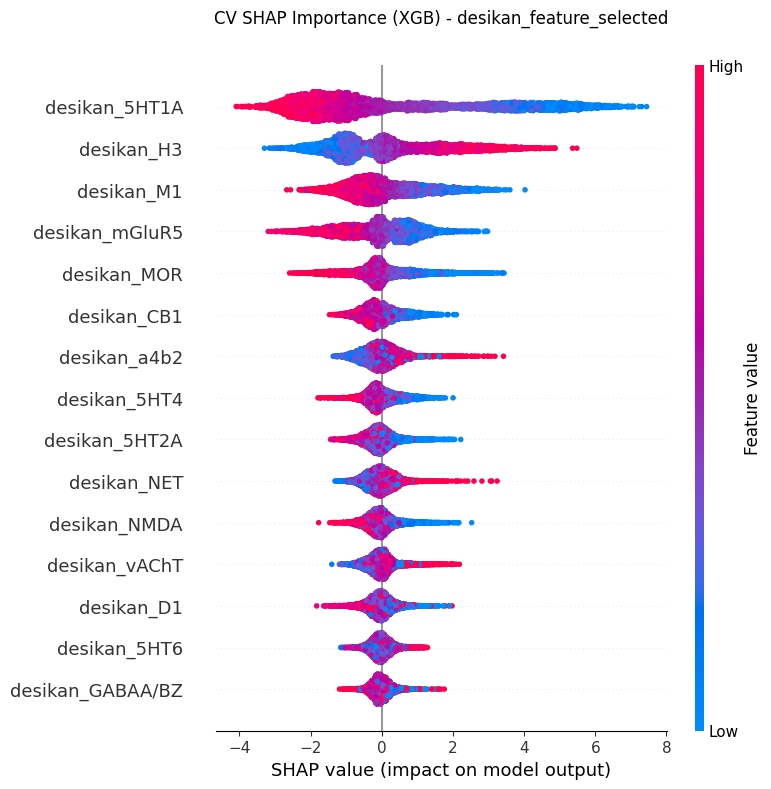

{'Desikan_feature_selected LR accuracy': [0.8733624454148472, 0.86608442503639, 0.8602620087336245, 0.8784570596797671, 0.8384279475982532], 'Desikan_feature_selected XGB accuracy': [0.8624454148471615, 0.8398835516739447, 0.8180494905385735, 0.8602620087336245, 0.8224163027656477], 'Desikan_feature_selected LR F1': [0.8426763110307414, 0.8603945371775418, 0.8309859154929577, 0.8417061611374408, 0.7827788649706457], 'Desikan_feature_selected XGB F1': [0.8295761947700632, 0.8264984227129337, 0.7747747747747747, 0.815028901734104, 0.7649325626204239], 'Desikan_feature_selected LR Sensitivity': [0.848816029143898, 0.8387573964497042, 0.8368794326241135, 0.8554913294797688, 0.7590132827324478], 'Desikan_feature_selected XGB Sensitivity': [0.8378870673952641, 0.7751479289940828, 0.7624113475177305, 0.815028901734104, 0.7533206831119544], 'Desikan_feature_selected LR AUC-PR': [0.9273349425916609, 0.9397453014902861, 0.9198284714069188, 0.9194869881296365, 0.8688315362321397], 'Desikan_featur

In [7]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from matplotlib import font_manager


font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

selected_cols = ['desikan_D1','desikan_NET', 'desikan_5HT1A', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']

df = df[(df['DIAGNOSIS'] == 1) | (df['DIAGNOSIS'] == 3)]

diags = df['DIAGNOSIS']

print(diags.value_counts())

desikan_df = df[['DIAGNOSIS'] + selected_cols].dropna()

desikan_diags = desikan_df['DIAGNOSIS'].map(lambda x: 0 if x == 1 else 1)

desikan_df = desikan_df.drop(columns = 'DIAGNOSIS')

scaler = StandardScaler()

seed = 42

kf = KFold()

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

X = desikan_df
y = desikan_diags
flag = 'desikan_feature_selected'

xgb_balancer = float(y[y == 0].shape[0])/ float(y[y == 1].shape[0])
print(xgb_balancer)

## Instantiate xgb with the balancer - mitigates class imbalance

xgb = XGBClassifier(random_state = seed, scale_pos_weight = xgb_balancer)

accuracies_lr = []
f1_scores_lr = []
sensitivities_lr = []
aucprs_lr = []

accuracies_xgb = []
f1_scores_xgb = []
sensitivities_xgb = []
aucprs_xgb = []

list_test_sets = list()

list_shap_values_xgb = list()

list_X_test_scaled = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train,y_test = y.iloc[train_index], y.iloc[test_index]

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    list_X_test_scaled.append(X_test)
        
    lr.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    lr_pred_diags = lr.predict(X_test)
    xgb_pred_diags = xgb.predict(X_test)

    lr_pred_probas = lr.predict_proba(X_test)[:,1]
    xgb_pred_probas = xgb.predict_proba(X_test)[:,1]

    precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_pred_probas)
    precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_pred_probas)
        
    aucpr_lr = auc(recall_lr, precision_lr)
    aucprs_lr.append(aucpr_lr)
    aucpr_xgb = auc(recall_xgb, precision_xgb)
    aucprs_xgb.append(aucpr_xgb)

        
    acc_lr = accuracy_score(y_test, lr_pred_diags)
    accuracies_lr.append(acc_lr)
    acc_xgb = accuracy_score(y_test, xgb_pred_diags)
    accuracies_xgb.append(acc_xgb)
    
    f1_lr = f1_score(y_test, lr_pred_diags)
    f1_scores_lr.append(f1_lr)
    f1_xgb = f1_score(y_test, xgb_pred_diags)
    f1_scores_xgb.append(f1_xgb)

    sensitivity_lr = recall_score(y_test, lr_pred_diags)
    sensitivities_lr.append(sensitivity_lr)
    sensitivity_xgb = recall_score(y_test, xgb_pred_diags)
    sensitivities_xgb.append(sensitivity_xgb)

    list_test_sets.append(test_index)# A list of the order of test set indexes

    xgb_explainer = shap.TreeExplainer(xgb)
    xgb_shap_values = xgb_explainer.shap_values(X_test)
    list_shap_values_xgb.append(xgb_shap_values) # A list of shap values
    
test_set = list_test_sets[0]
shap_values_xgb = np.array(list_shap_values_xgb[0])

X_scaled_full = np.concatenate(list_X_test_scaled, axis=0)
for n in range(1,len(list_test_sets)):
    test_set = np.concatenate((test_set,list_test_sets[n]),axis=0)
    print(test_set)
    shap_values_xgb = np.concatenate((shap_values_xgb, np.array(list_shap_values_xgb[n])),axis = 0)
    
print('FEATURE SELECTED XGB SHAP INCOMING...')
print(shap_values_xgb.shape)
X_reordered = X.iloc[test_set]
shap.summary_plot(shap_values_xgb, X_reordered, show=False)    
plt.title(f'CV SHAP Importance (XGB) - {flag}', y=1.05)
plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_xgb_shap_beeswarm_{flag}.png',dpi=600)
plt.show()
plt.close()



flag_u = flag.capitalize()

data = {
    f"{flag_u} LR accuracy": accuracies_lr,
    f"{flag_u} XGB accuracy": accuracies_xgb,
    f"{flag_u} LR F1": f1_scores_lr,
    f"{flag_u} XGB F1": f1_scores_xgb,
    f"{flag_u} LR Sensitivity": sensitivities_lr,
    f"{flag_u} XGB Sensitivity": sensitivities_xgb,
    f"{flag_u} LR AUC-PR": aucprs_lr,
    f"{flag_u} XGB AUC-PR": aucprs_xgb}

print(data)

for key, vals in data.items():
    print(key, len(vals))

df = pd.DataFrame(data)

print(df)

df.to_csv(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_fold_metrics_{flag}.csv', index = False)
        

### Are the feature selected performances of LR and XGB similar to each other?

In [8]:
import pandas as pd
import numpy as np
import os
import re
import scipy
from scipy.stats import wilcoxon


df = pd.read_csv(os.path.join('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_fold_metrics_desikan_feature_selected.csv'), low_memory = False)

accuracies = df[['Desikan_feature_selected LR accuracy', 'Desikan_feature_selected XGB accuracy']]
f1s = df[['Desikan_feature_selected LR F1', 'Desikan_feature_selected XGB F1']]
sensitivities = df[['Desikan_feature_selected LR Sensitivity', 'Desikan_feature_selected XGB Sensitivity']]
aucprs = df[['Desikan_feature_selected LR AUC-PR', 'Desikan_feature_selected XGB AUC-PR']]

thresh = len([accuracies, f1s, sensitivities, aucprs])

for n in [accuracies, f1s, sensitivities, aucprs]:
    print(n)
    print(n.values[:,0], n.values[:,1])
    res = wilcoxon(n.values[:,0], n.values[:,1])
    print(res.pvalue)
    print(bool(res.pvalue < float(0.05/thresh)))
    print(' ')

   Desikan_feature_selected LR accuracy  Desikan_feature_selected XGB accuracy
0                              0.873362                               0.862445
1                              0.866084                               0.839884
2                              0.860262                               0.818049
3                              0.878457                               0.860262
4                              0.838428                               0.822416
[0.87336245 0.86608443 0.86026201 0.87845706 0.83842795] [0.86244541 0.83988355 0.81804949 0.86026201 0.8224163 ]
0.0625
False
 
   Desikan_feature_selected LR F1  Desikan_feature_selected XGB F1
0                        0.842676                         0.829576
1                        0.860395                         0.826498
2                        0.830986                         0.774775
3                        0.841706                         0.815029
4                        0.782779                         0.76

#### Does the feature-selected LR performance beat other LR performances?

In [9]:
import pandas as pd
import os
import numpy as np

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'

coeff_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_coeffs.csv'))
vbm_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_vbm.csv'))
cort_thick_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_cort_thick.csv'))
roi_gmv_csv = pd.read_csv(os.path.join(root_path, 'fold_metrics_desikan_roi_gmv.csv'))
feature_selected_csv = pd.read_csv(os.path.join(root_path, 'feature_selected_fold_metrics_desikan_feature_selected.csv'))

lr_df = coeff_csv[[col for col in coeff_csv.columns.tolist() if 'LR' in col.split(' ')]].join(vbm_csv[[col for col in vbm_csv.columns.tolist() if 'LR' in col.split(' ')]])
lr_df = lr_df.join(cort_thick_csv[[col for col in cort_thick_csv.columns.tolist() if 'LR' in col.split(' ')]])
lr_df = lr_df.join(roi_gmv_csv[[col for col in roi_gmv_csv.columns.tolist() if 'LR' in col.split(' ')]])
lr_df = lr_df.join(feature_selected_csv[[col for col in feature_selected_csv.columns.tolist() if 'LR' in col.split(' ')]])


acc_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'accuracy' in col.split(' ')]].mean()
f1_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'F1' in col.split(' ')]].mean()
sens_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'Sensitivity' in col.split(' ')]].mean()
aucpr_lr_df = lr_df[[col for col in lr_df.columns.tolist() if 'AUC-PR' in col.split(' ')]].mean()

coeff_points = 0
vbm_points = 0
ct_points = 0
roi_gmv_points = 0

for mean_metrics in [acc_lr_df, f1_lr_df, sens_lr_df, aucpr_lr_df]:
    print(mean_metrics.idxmax(), mean_metrics.max())

Desikan_coeffs LR accuracy 0.8646288209606986
Desikan_coeffs LR F1 0.833282222964787
Desikan_roi_gmv LR Sensitivity 0.8479240854442406
Desikan_roi_gmv LR AUC-PR 0.9199505768298339
